In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
from builtins import range, input

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import numpy as np


from glob import glob
import pandas as pd
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer


print("All libraries are imported")

All libraries are imported


In [2]:
#define size to which images are to be resized
IMAGE_SIZE = [250, 250]

# training config:
epochs = 200
batch_size = 32

#define paths
covid_path = "D:\Internship NMAM\COVID"
noncovid_path = r"D:\Internship NMAM\non-COVID"

# Use glob to grab images from path .jpg or jpeg
covid_files = glob(covid_path + '/*')
noncovid_files = glob(noncovid_path + '/*')


In [3]:
# Visualize file variable contents
print("First 5 Covid Files: ",covid_files[0:5])
print("_________________________________________________________________________________________________________________________")
print("Total Count: ",len(covid_files))
print("_________________________________________________________________________________________________________________________")
print("First 5 NonCovid Files: ",noncovid_files[0:5])
print("_________________________________________________________________________________________________________________________")
print("Total Count: ",len(noncovid_files))

First 5 Covid Files:  ['D:\\Internship NMAM\\COVID\\Covid (1).png', 'D:\\Internship NMAM\\COVID\\Covid (10).png', 'D:\\Internship NMAM\\COVID\\Covid (100).png', 'D:\\Internship NMAM\\COVID\\Covid (1000).png', 'D:\\Internship NMAM\\COVID\\Covid (1001).png']
_________________________________________________________________________________________________________________________
Total Count:  1252
_________________________________________________________________________________________________________________________
First 5 NonCovid Files:  ['D:\\Internship NMAM\\non-COVID\\Non-Covid (1).png', 'D:\\Internship NMAM\\non-COVID\\Non-Covid (10).png', 'D:\\Internship NMAM\\non-COVID\\Non-Covid (100).png', 'D:\\Internship NMAM\\non-COVID\\Non-Covid (1000).png', 'D:\\Internship NMAM\\non-COVID\\Non-Covid (1001).png']
_________________________________________________________________________________________________________________________
Total Count:  1229


In [4]:
covid_labels = []                                   
noncovid_labels = []

covid_images=[]                                      
noncovid_images=[]

for i in range(len(covid_files)):
  image = cv2.imread(covid_files[i])                  
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)      
  image = cv2.resize(image,(250,250))                 
  covid_images.append(image)                        
  covid_labels.append(0)#append class to labels
  
for i in range(len(noncovid_files)):
  image = cv2.imread(noncovid_files[i])
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  image = cv2.resize(image,(250,250))
  noncovid_images.append(image)
  noncovid_labels.append(1)

In [5]:
def plot_images_from_datasets(images, title):
    nrows, ncols = 5, 8
    figsize = [10, 6]

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, facecolor=(1, 1, 1))

    for i, axi in enumerate(ax.flat):
        axi.imshow(images[i])
        axi.set_axis_off()

    plt.suptitle(title, fontsize=20)
    plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.9])
    plt.show()

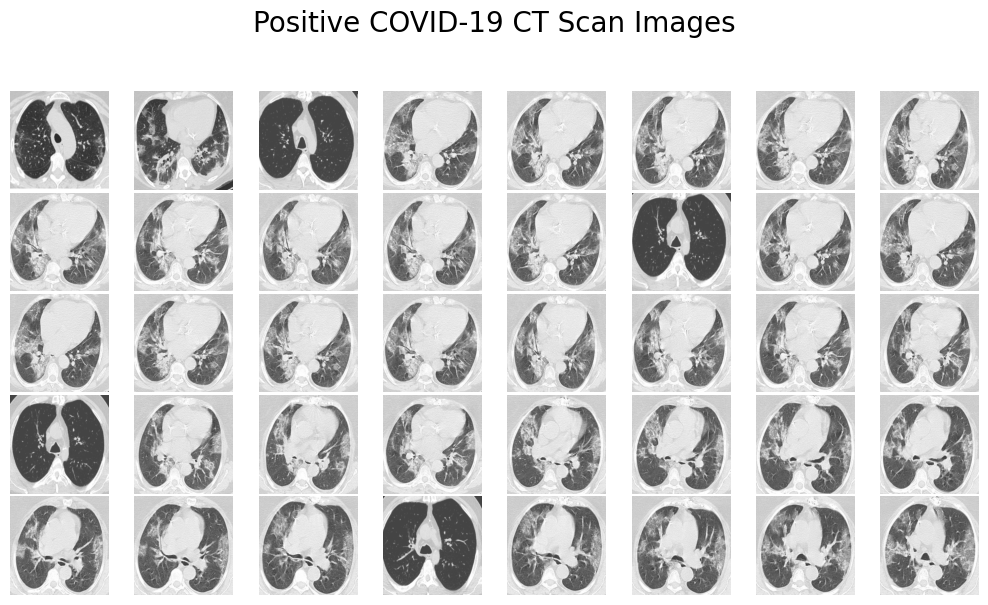

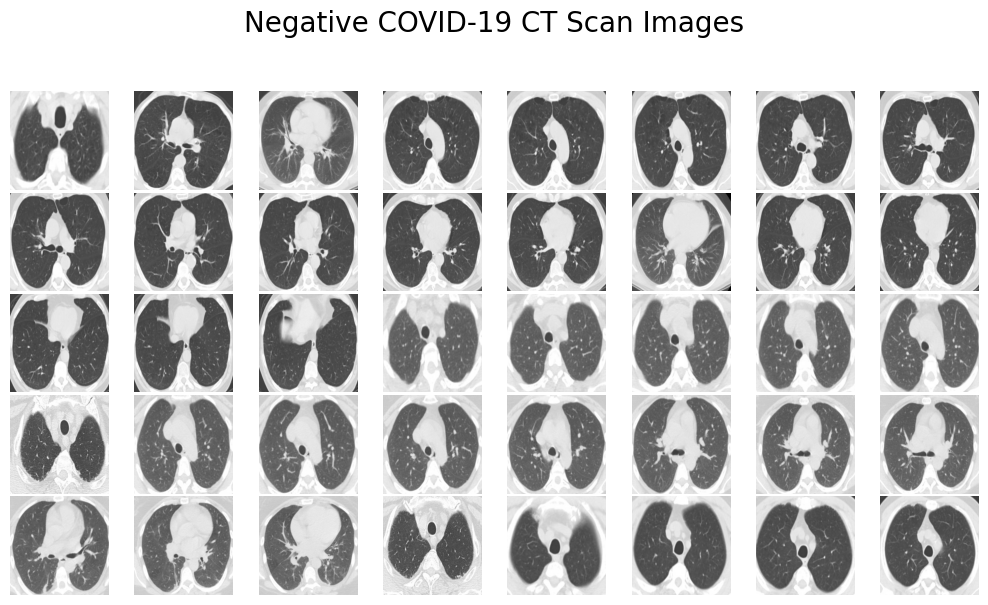

In [6]:
# Plotting the Positive COVID and Negative COVID datasets

plot_images_from_datasets(covid_images, 'Positive COVID-19 CT Scan Images')
plot_images_from_datasets(noncovid_images, 'Negative COVID-19 CT Scan Images')

# Convert to array and Normalize to interval
covid_images = np.array(covid_images) / 255
noncovid_images = np.array(noncovid_images) / 255

In [7]:
# Split into training and testing sets 

# COVID Positive 
covid_x_train, covid_x_test, covid_y_train, covid_y_test = train_test_split(
    covid_images, covid_labels, test_size=0.2)

#COVID Negative
noncovid_x_train, noncovid_x_test, noncovid_y_train, noncovid_y_test = train_test_split(
    noncovid_images, noncovid_labels, test_size=0.2)

# Merge sets for both types of images
X_train = np.concatenate((noncovid_x_train, covid_x_train), axis=0)
X_test = np.concatenate((noncovid_x_test, covid_x_test), axis=0)
y_train = np.concatenate((noncovid_y_train, covid_y_train), axis=0)
y_test = np.concatenate((noncovid_y_test, covid_y_test), axis=0)

16/16 [==============================] - 27s 2s/step


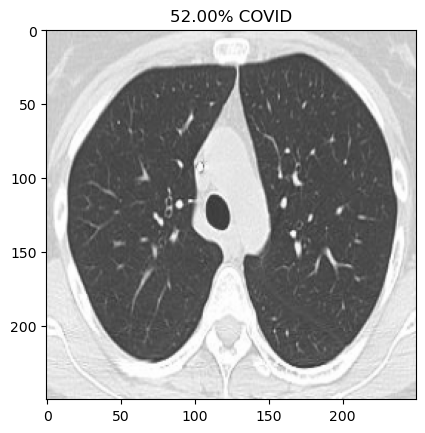

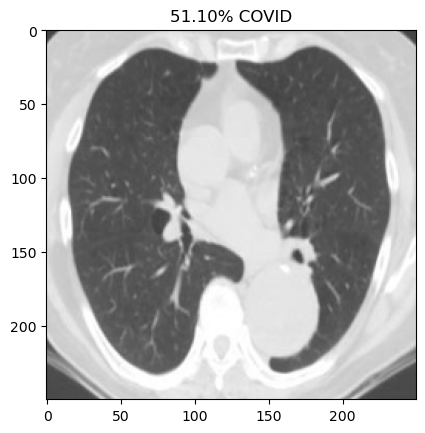

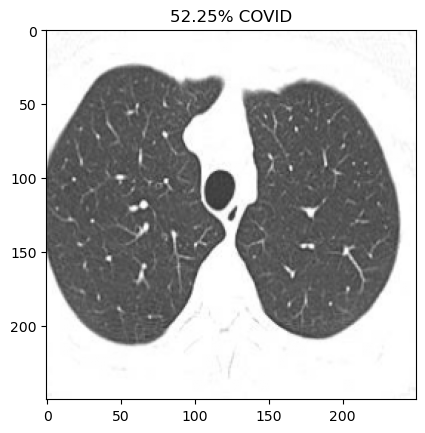

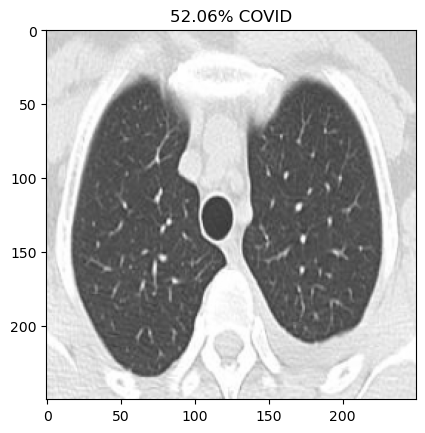

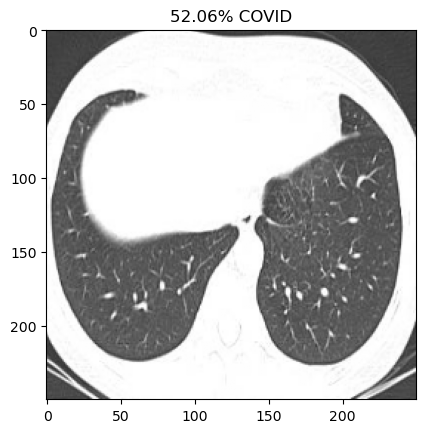

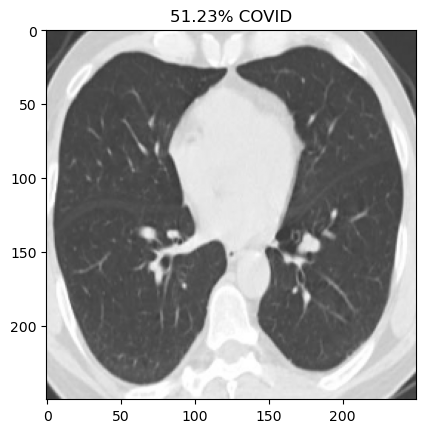

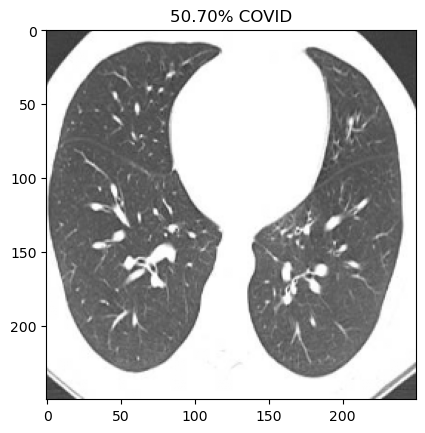

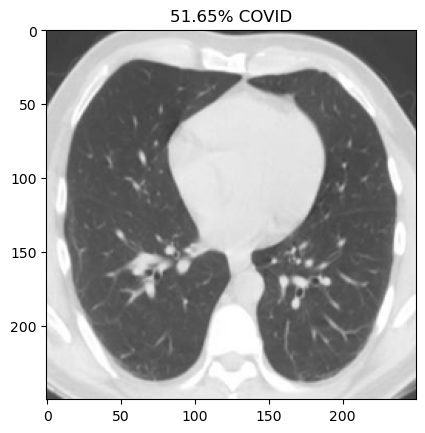

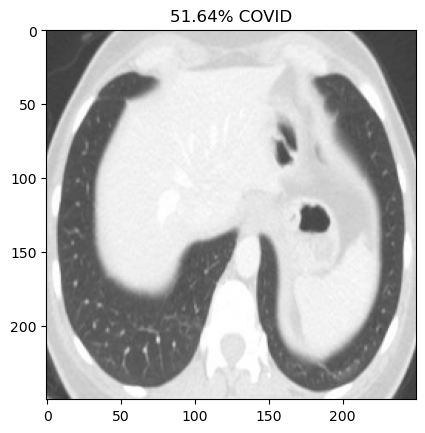

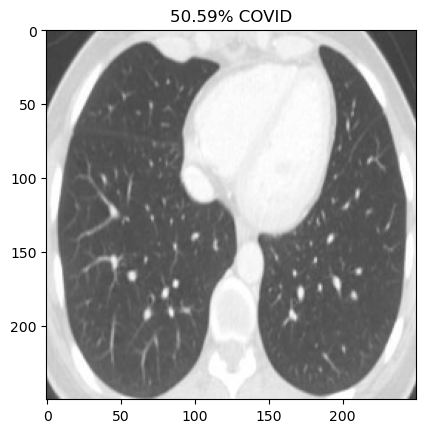

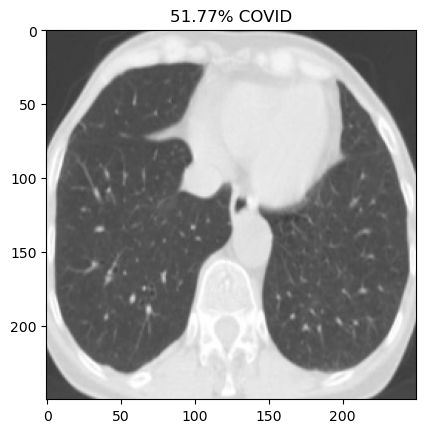

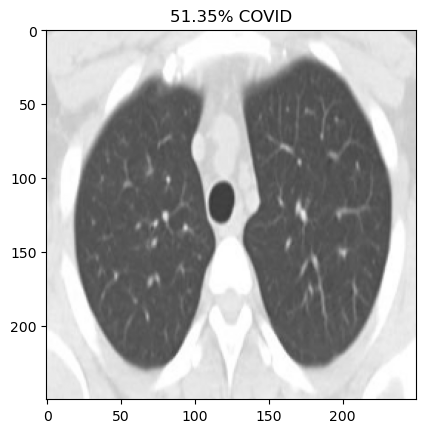

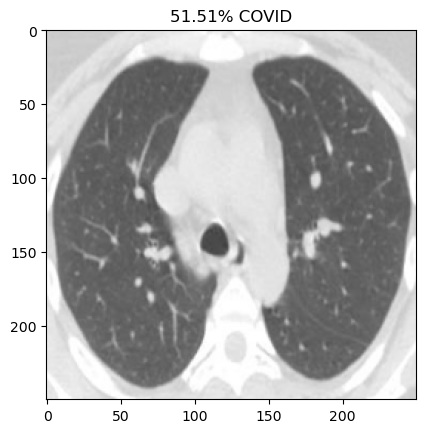

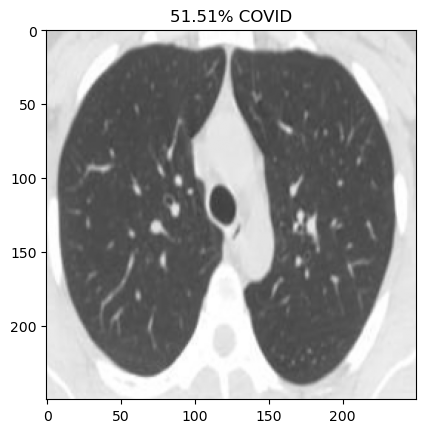

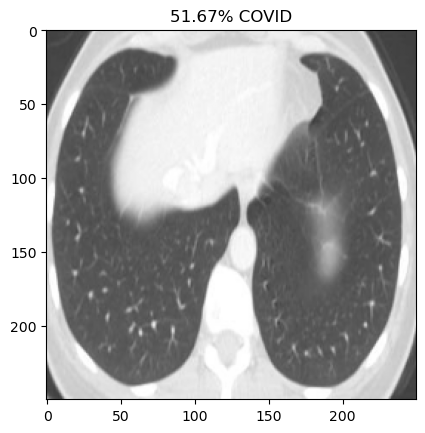

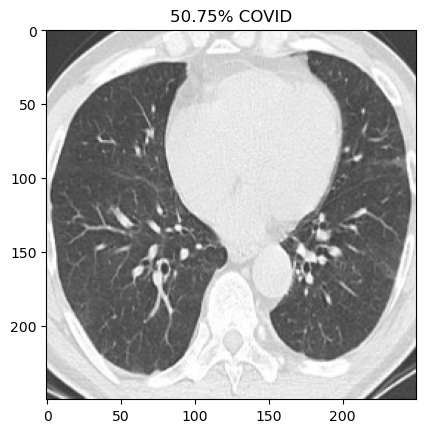

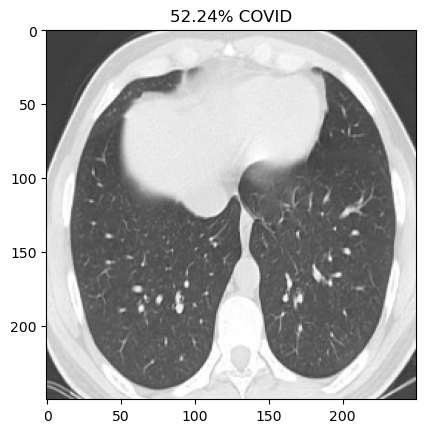

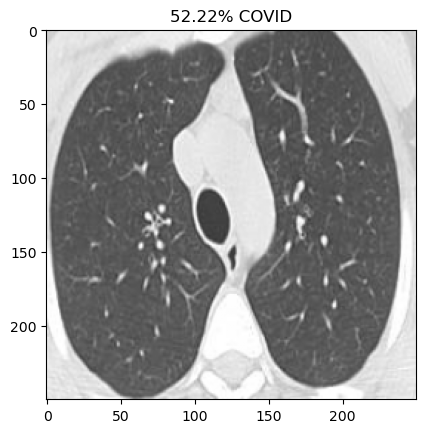

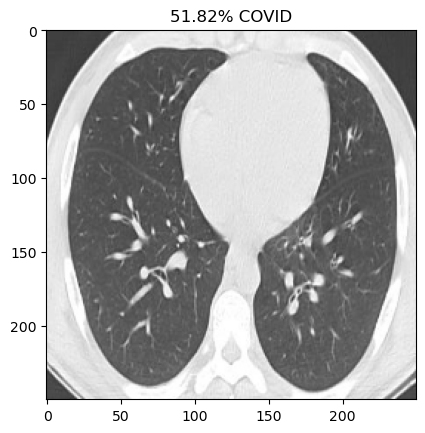

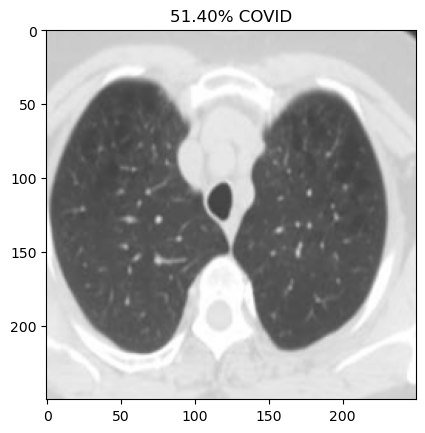

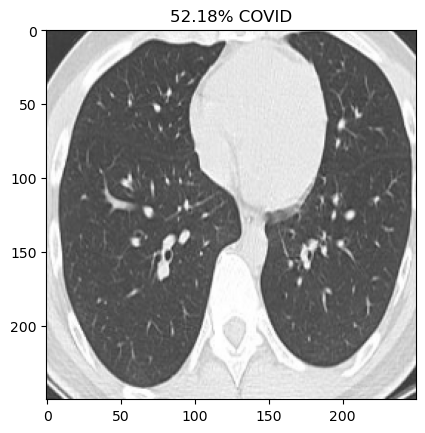

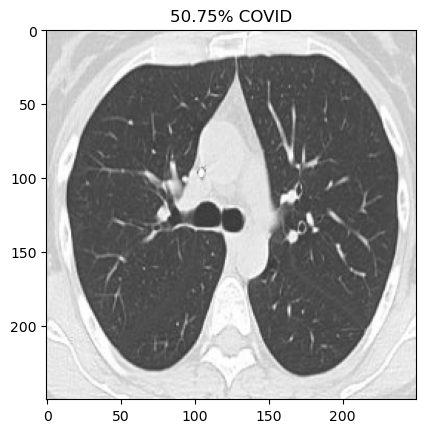

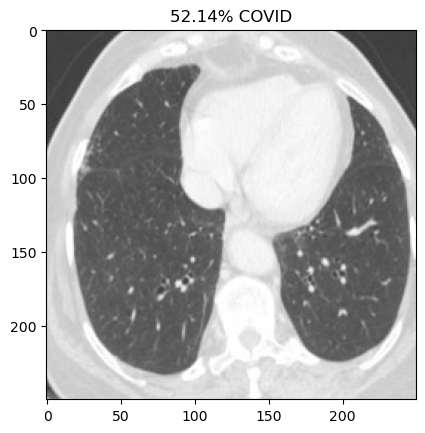

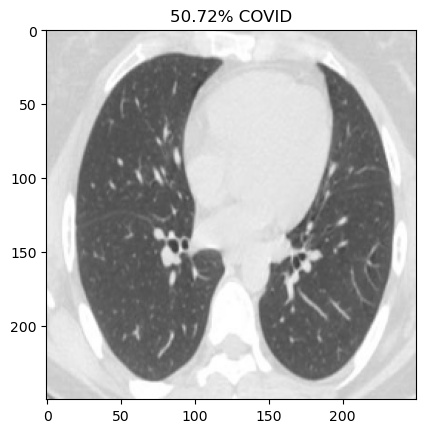

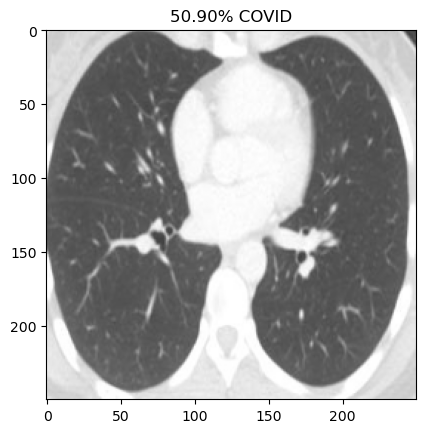

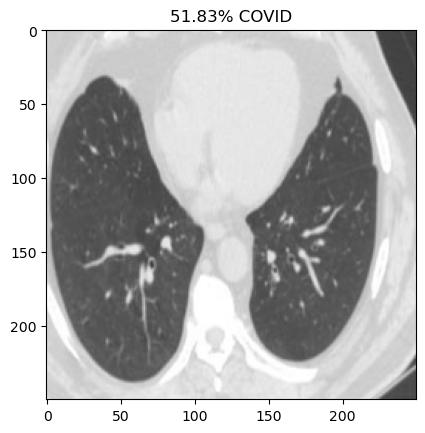

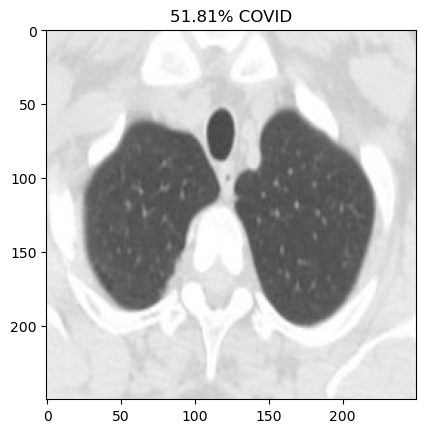

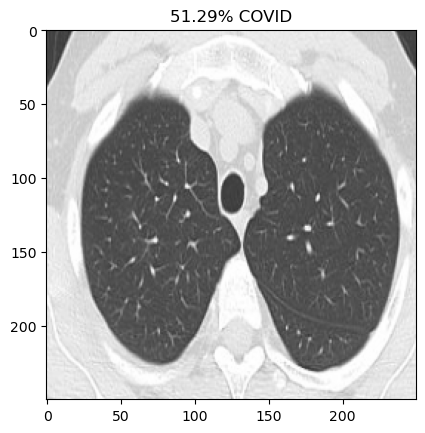

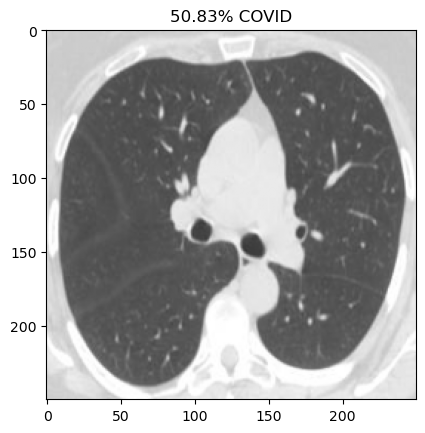

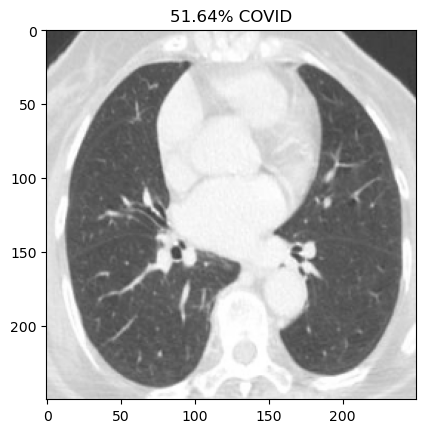

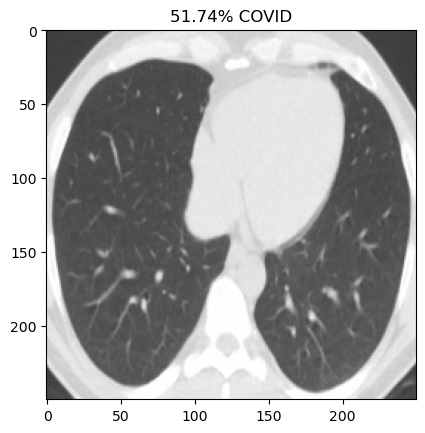

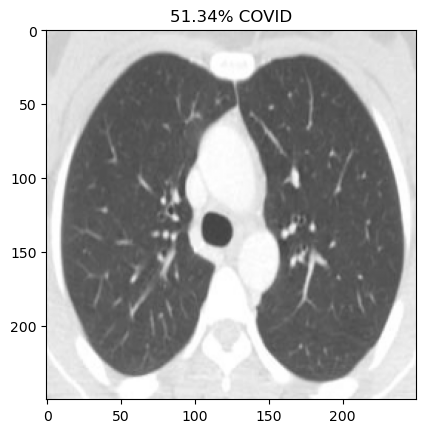

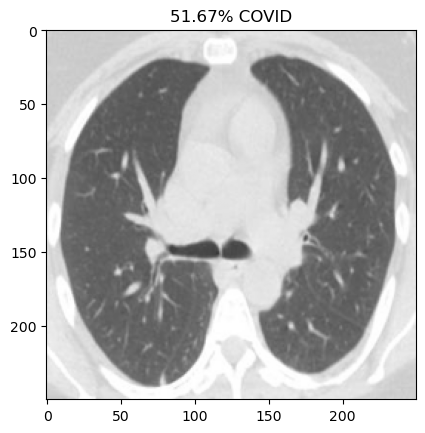

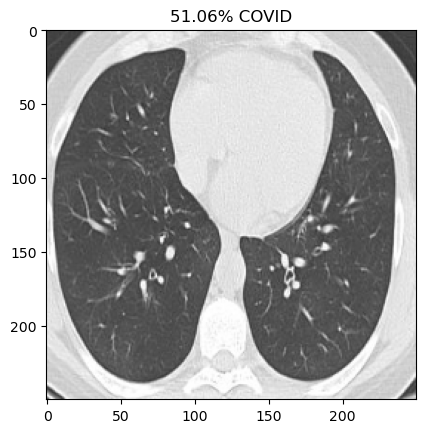

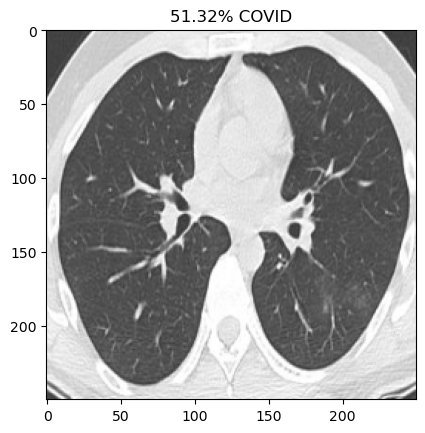

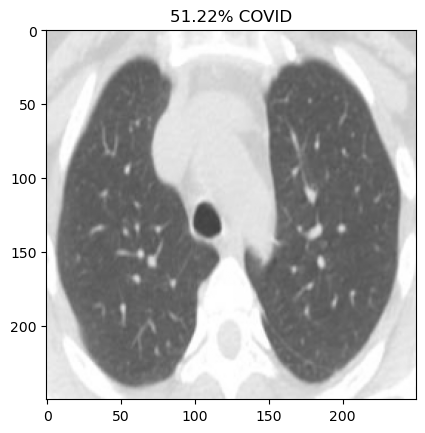

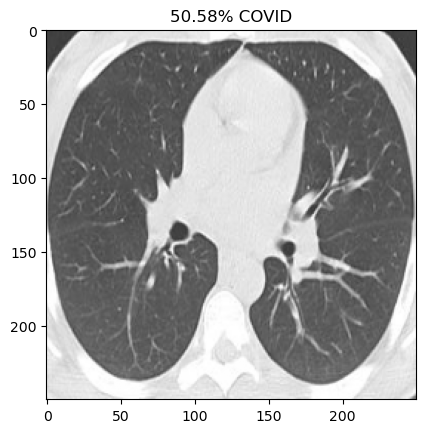

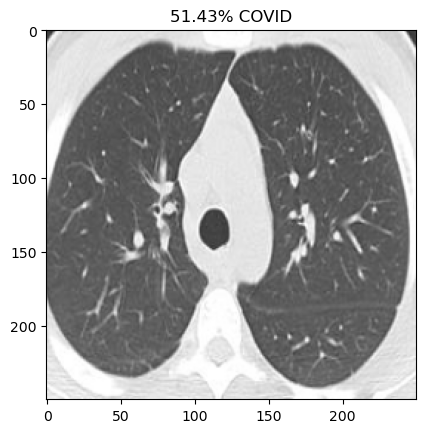

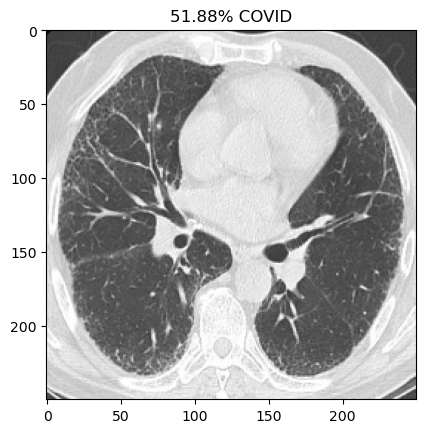

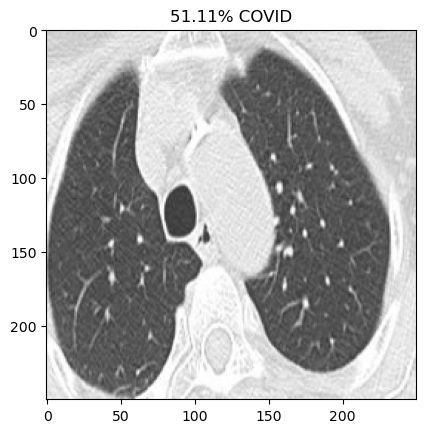

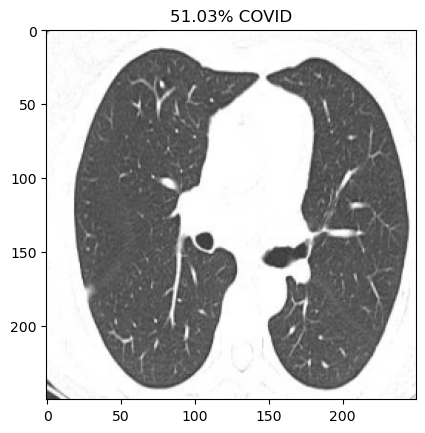

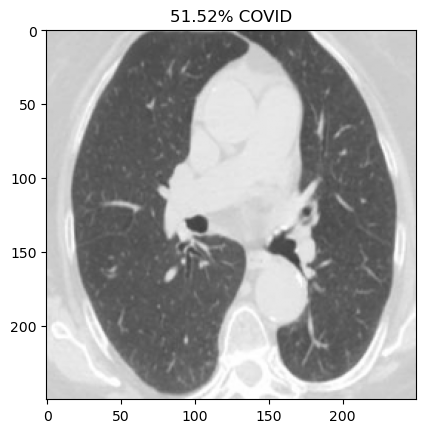

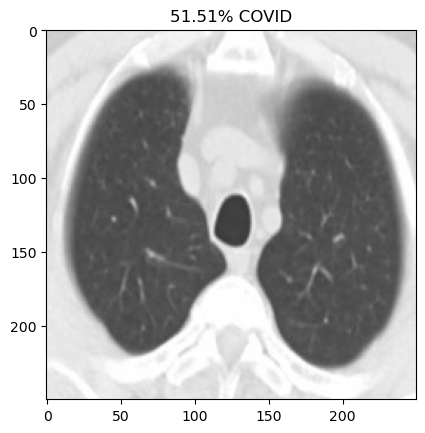

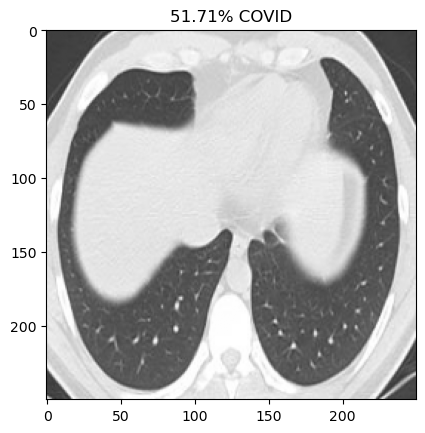

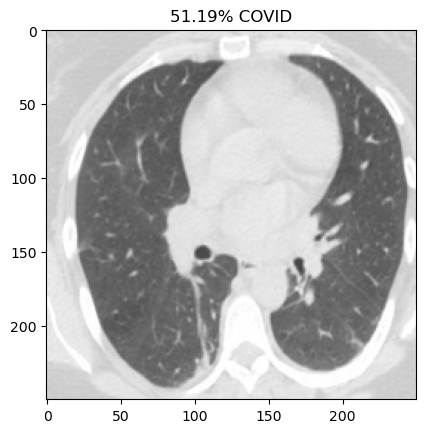

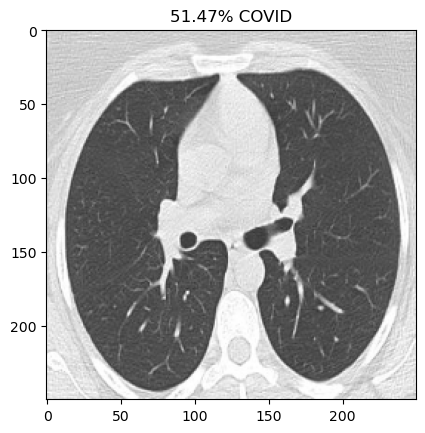

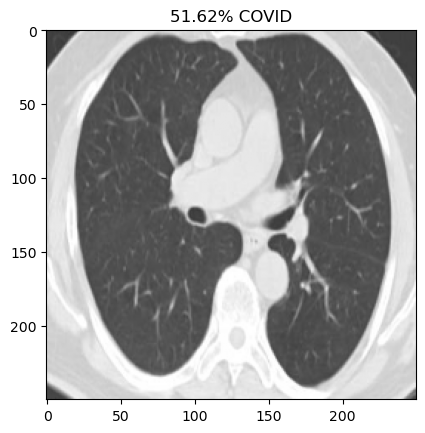

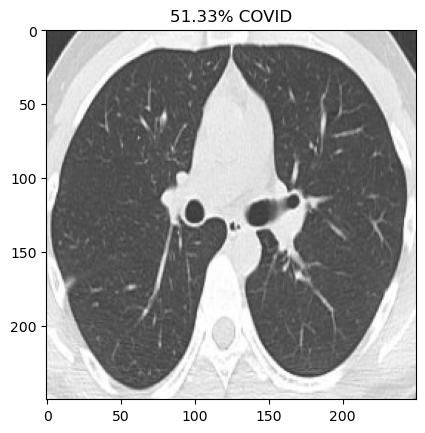

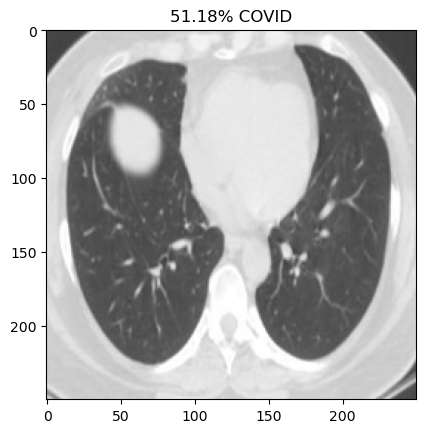

In [8]:
# Load saved model
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model



model = load_model('my_modell.h5')
y_pred = model.predict(X_test, batch_size=batch_size)
# # Reshape your input data to (None, 784)
# X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
# # Assuming X_test has shape (None, 250, 250, 3)
# X_test_reshaped = X_test.reshape(X_test.shape[0], -1)  # Reshape to (None, 250*250*3)
# #y_pred = model.predict(X_test_reshaped, batch_size=batch_size)
# y_pred = model.predict(X_test_reshaped)
X_test_reshaped = X_test.reshape(X_test.shape[0], 250, 250, 3)

# Make predictions using the reshaped data
y_pred = model.predict(X_test_reshaped, batch_size=batch_size)
#y_pred = model.predict(X_test, batch_size=batch_size)

#Let's Look the 1 to 50 images#

prediction=y_pred[1:50]
for index, probability in enumerate(prediction):
#for index, probability in enumerate(y_pred[:50]):
   if probability[0] > 0.5:
        plt.title('%.2f' % (probability[0]*100) + '% COVID')
   else:
        plt.title('%.2f' % ((1-probability[0])*100) + '% NonCOVID')
   plt.imshow(X_test[index])
   plt.show()

In [9]:
import tensorflow as tf

# Define a model that accepts input shape (250, 250, 3)
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(250, 250, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Example output layer for binary classification
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Example loss function for binary classification
                  metrics=['accuracy'])

    return model

# Create the model
model = create_model()

# Save the model to an HDF5 file
#model.save('my_modell.h5')


1/1 [==============================] - 0s 271ms/step


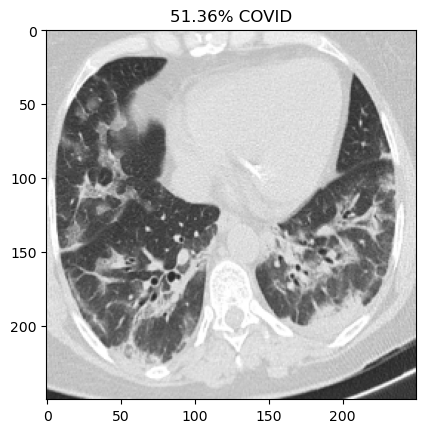

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model

# Suppress FutureWarnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load your model
model = load_model('my_modell.h5')  # Load your model here

# Load the image and preprocess
img = cv2.imread(r"D:\Internship NMAM\COVID\Covid (11).png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (250, 250))
x = img_to_array(img)  # Convert image to numpy array

# Normalize pixel values
x = x / 255.0

# Reshape the image according to the model's input shape
x = np.expand_dims(x, axis=0)  # Shape will become (1, 250, 250, 3)

# Make prediction
predictions = model.predict(x)

# Interpret the prediction
if predictions[0][0] > 0.5:
    plt.title('%.2f' % (predictions[0][0] * 100) + '% COVID')
else:
    plt.title('%.2f' % ((1 - predictions[0][0]) * 100) + '% NonCOVID')

plt.imshow(img)
plt.show()


1/1 [==============================] - 0s 337ms/step
[[0.50741225]]


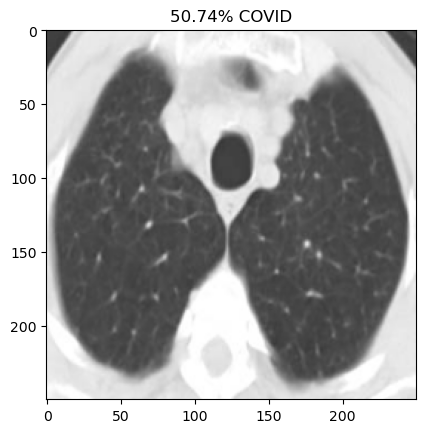

In [11]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model

# Load your model
model = load_model('my_modell.h5')  # Load your model here

# File path using raw string notation
img_path = r"D:\Internship NMAM\non-COVID\Non-Covid (3).png"

# Load the image using try-except block to handle exceptions
try:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Unable to load image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (250, 250))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)
    x /= 255.0  # Normalize pixel values

    successive_feature_maps = model.predict(x)
    print(successive_feature_maps)

    for index, probability in enumerate(successive_feature_maps):
        if probability[0] > 0.5:
            plt.title('%.2f' % (probability[0] * 100) + '% COVID')
        else:
            plt.title('%.2f' % ((1 - probability[0]) * 100) + '% NonCOVID')
        plt.imshow(img)
        plt.show()
except Exception as e:
    print("Error:", e)


16/16 [==============================] - 27s 2s/step


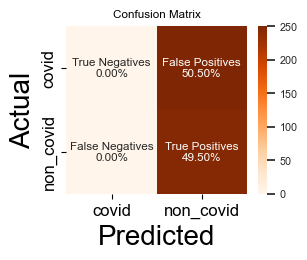

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Load saved model
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

#batch_size=10

model = load_model('my_modell.h5')
y_pred = model.predict(X_test, batch_size=batch_size)
X_test_reshaped = X_test.reshape(X_test.shape[0], 250, 250, 3)

# Make predictions using the reshaped data
y_pred = model.predict(X_test_reshaped, batch_size=batch_size)
#y_pred = model.predict(X_test, batch_size=batch_size)


plt.subplot(2,2,3)
      # Set up the labels for in the confusion matrix
y_true=y_test

y_pred_binary = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred_binary)
names = ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']
counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f'{v1}\n{v2}' for v1, v2 in zip(names, percentages)]
labels = np.asarray(labels).reshape(2,2)
ticklabels = ['covid', 'non_covid']

      # Create confusion matrix as heatmap
sns.set(font_scale = 0.7)
ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Oranges', xticklabels=ticklabels, yticklabels=ticklabels )
plt.xticks(size=12)
plt.yticks(size=12)
plt.title("Confusion Matrix") #plt.title("Confusion Matrix\n", fontsize=10)
plt.xlabel("Predicted", size=20)
plt.ylabel("Actual", size=20) 
plt.savefig('cm.png', transparent=True) 
 


In [13]:
#recall,f1_score,precision
from sklearn.metrics import precision_score,recall_score,f1_score
print(precision_score(y_test,y_pred_binary))
print(recall_score(y_test,y_pred_binary))
print(f1_score(y_test,y_pred_binary))

0.4949698189134809
1.0
0.6621803499327054
